## Two Moon Problem Setup

**1. Prior Sampling:**
- The prior is uniform over $[-1, 1]^2$. 

**2. Two Moons Simulator:**
- The simulator follows the equations provided:
    - $a \sim U(-\pi/2, \pi/2)$ : Random angle
    - $ r \sim N(0.1, 0.01^2)$ : Random radius with Gaussian noise
    - p is computed based on a and r, forming the crescent
      $$
      p = (r cos(a) + 0.25, r sin(a))
      $$

    - shift is applied using the parameter $\theta = [\theta_1, \theta_2]$
      $$
      x = p + \left(\frac{|\theta_1 + \theta_2|}{\sqrt{2}}, \frac{-\theta_1 + \theta_2}{\sqrt{2}} \right)
      $$

**3. True observation:**
$observation = [0,0]$




 



### SBI 

In [1]:
import lfi
import torch
import numpy as np
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### NPE-A budget=1_000

In [2]:
np.random.seed(21355)
torch.manual_seed(21)

In [3]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [4]:
# inference parameters
budget=1000
num_components=10
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [5]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [6]:
# Define inference
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [7]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 336 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [8]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

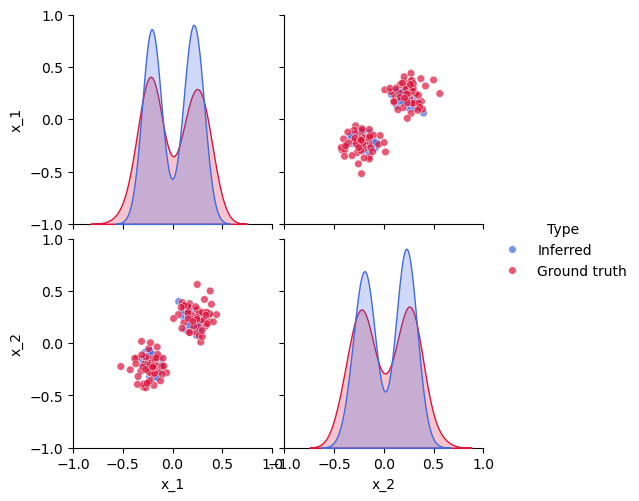

In [10]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [11]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.6399999999999999


### NPEA_A - budget:10_000

In [12]:
np.random.seed(21355)
torch.manual_seed(21)

In [13]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [14]:
# inference parameters
budget=10000
num_components=10
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [15]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [16]:
# Define inference
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [17]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 179 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [18]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

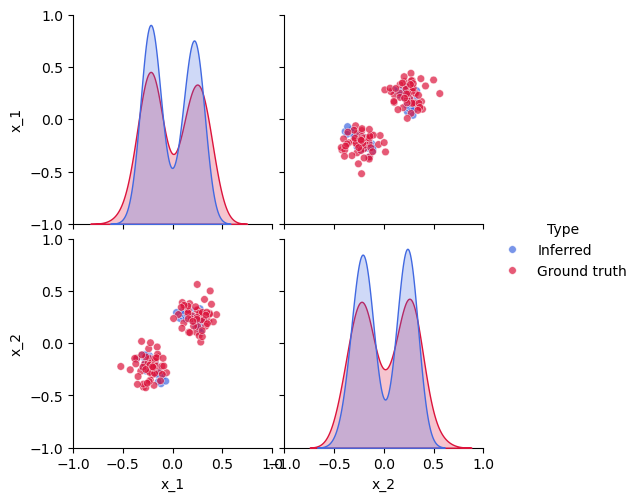

In [20]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [21]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.7300000000000001


### NPE_A, budget:50_000

In [22]:
np.random.seed(21355)
torch.manual_seed(21)

In [23]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [24]:
# inference parameters
budget=50_000
batch_size=1000
num_components=10
max_num_epochs = 1000
nof_samples=100

In [25]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [26]:
# Define inference
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [27]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components,
    }
)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 103 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [28]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [29]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

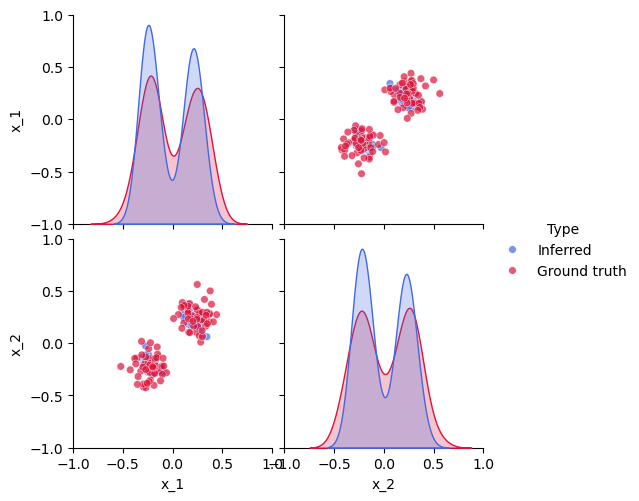

In [30]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [31]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.7300000000000001


### NPE_C, budget: 1_000

In [32]:
np.random.seed(21355)
torch.manual_seed(21)

In [33]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [34]:
# inference parameters
budget=1000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [35]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [36]:
# Define inference
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [37]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 220 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [38]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

 C:\Users\Theodora\anaconda3\envs\pytorch2\lib\site-packages\nflows\transforms\lu.py:80: UserWarning:torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\BatchLinearAlgebra.cpp:2198.)


In [39]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

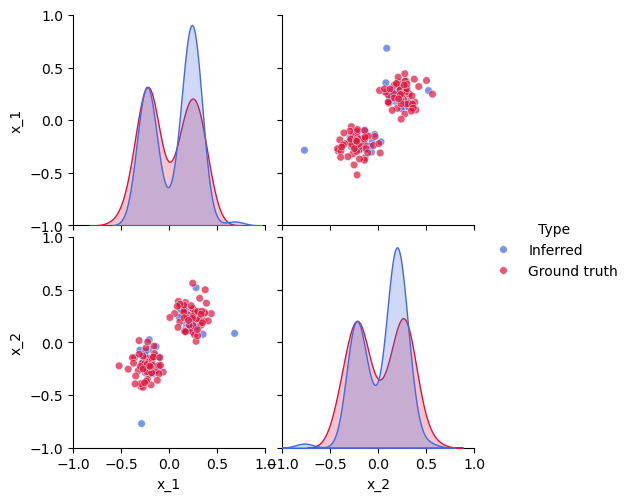

In [40]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [41]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.6599999999999999


### NPE_C, budget:10_000

In [42]:
np.random.seed(21355)
torch.manual_seed(21)

In [43]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [44]:
# inference parameters
budget=10000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [45]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [46]:
# Define inference
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [47]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 108 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [48]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [49]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

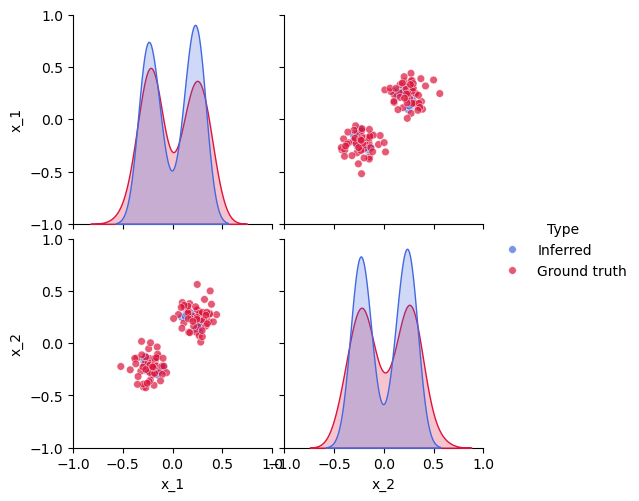

In [50]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [51]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.8550000000000001


### NPE_C: budget:50_000

In [52]:
np.random.seed(21355)
torch.manual_seed(21)

In [53]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [54]:
# inference parameters
budget=50000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [55]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [56]:
# Define inference
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [57]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 144 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [58]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [59]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

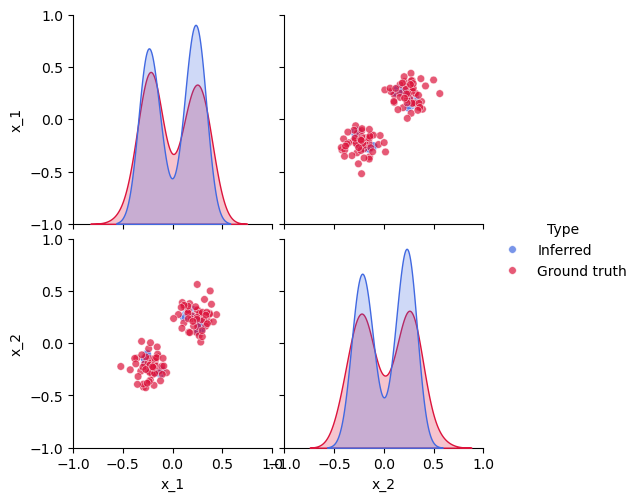

In [60]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [61]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.8550000000000001


### FMPE, budget:1_000

In [62]:
np.random.seed(21355)
torch.manual_seed(21)

In [63]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [64]:
# inference parameters
budget=1000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [65]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [66]:
# Define inference
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [67]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 68 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [68]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [69]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

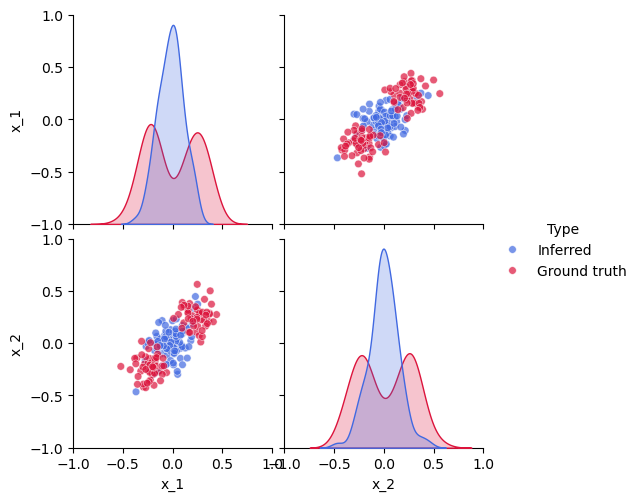

In [70]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [71]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.8450000000000001


### FMPE-budget:10_000

In [72]:
np.random.seed(21355)
torch.manual_seed(21)

In [73]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [74]:
# inference parameters
budget=10000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [75]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [76]:
# Define inference
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [77]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 72 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [78]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [79]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

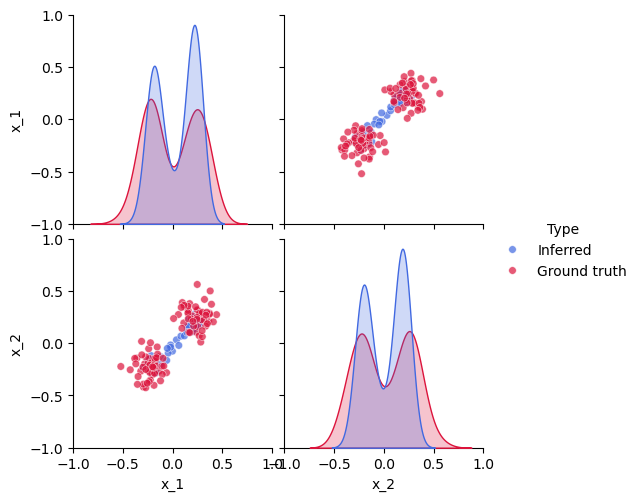

In [80]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [81]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.795


### FMPE, budget: 50_000

In [82]:
np.random.seed(21355)
torch.manual_seed(21)

In [83]:
# Modeling parameters
prior_low=-1
prior_high=+1
simulator_dim_y = 2
prior_dim=2
observation_nof_obs=1

In [84]:
# inference parameters
budget=50000
batch_size=1000
max_num_epochs = 1000
nof_samples=100

In [85]:
prior=lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.TwoMoon(dim=prior_dim, dim_y=simulator_dim_y)
obs = lfi.observations.Zeros(dim_y = simulator_dim_y, nof_observations=observation_nof_obs)
observation = obs.sample()

In [86]:
# Define inference
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [87]:
# Fit
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
    }
)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 59 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [88]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [89]:
from scipy.stats import multivariate_normal
mode1 = np.array([0.25, 0.25])
mode2 = np.array([-0.25, -0.25])
cov = 0.01 * np.eye(2)  # Small covariance

# Generate GT samples (50% from each mode)
samples_gt = np.vstack([
    multivariate_normal(mode1, cov).rvs(50),
    multivariate_normal(mode2, cov).rvs(50)
])

<Figure size 640x480 with 0 Axes>

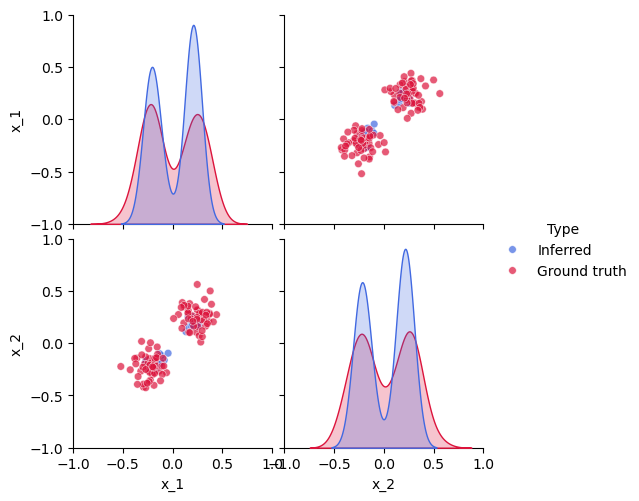

In [90]:
lfi.visualization.plot_pairwise_posterior(
    samples, 
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)
plt.show()

In [91]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st metric is: {c2st}")

c2st metric is: 0.7950000000000002
